# Librerias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
import json
import requests
from bs4 import BeautifulSoup as bs
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error
from datetime import datetime

# utils

In [ ]:
#que sea la ultima clase o ayudantia no implica que tenga su contenido
#ultima clase revisada == 21
#ultima ayudantia revisada == 8

#contenidos que me salte:

#ambas sobre web scrapping y cosas por el estilo
#clase 06 y clase 07 y ayudantia 04

#ayudantia 8 llena de graficos

#segunda mitad de clase 13 (sobre geopandas y pivot)

#clase 14 (un grafico raro al final de la clase, todo el resto esta)

In [ ]:
# Clases 16 y 17 hay bastantes graficos de seaborn
# clase 19 hay modelos de regresion
# ayudantia 9 - archivo de practica hay algo breve sobre cruzar unos datos con un mapa

# Navegación entre carpetas

In [ ]:
# entrega la ruta del directorio actual
%pwd

# lista el contenido de del directorio actual
%ls 

# cambia al directorio seleccionado
cd "subdirectorio"
    
# se devuelve al directorio anterior
%cd ..

# Datatime

In [ ]:
df["nombre_columna"] = pd.to_datetime(df["nombre_columna"], format='%d-%m-%Y')
df["nombre_columna"]

# pyarrow

In [ ]:
# leer base de datos (.parque)
df = pq.read_table("ruta")

# pandas

#### pasar a formato de pandas o convertir en dataframes

In [ ]:
# tranformar archivos a dataframes de pandas
nombre_archivo.to_pandas()

# tranformar json a dataframe de pandas (no muy recomendable)
df = pd.DataFrame(json_list)

#### metodos varios para dataframes

In [ ]:
# leer e ispeccionar un dataframe

# muestra las primeras x filas de un dataframe
df.head(x)

# muestra las ultimas x filas de un dataframe
df.tail(x)

# muestra x columnas aleatorias
df.sample(x)

# muestra informacion sobre cada columna
df.info()

# nombres de las columnas
df.columns

# obtener datos de una columna especifica
df["nombre_columna"]

# obtener una fila x del dataframe
df["nombre_columna"][x]

# localizar un elemento por id
df.loc[posicion]

# acceder a filas especificas (quedarnos con columnas especificas)
resumen = df[["nombre_columna_A", "nombre_columna_B"]]

# filtrar para un dato especifico 
datos_buscados = df[df["nombre_columna"]=="dato"]
# se le puede agregar para que se cumpla otra condicion, y asi indefinidamente
datos_buscados = df[(df["nombre_columna_A"]=="dato") & (df["nombre_columna_V"]=="dato")]

# los dataframe se pueden indexar
df.iloc[x:y]

# información estadística por cada columna
df.describe()

# ver tipo de datos de cada columna
df.dtypes

# ver los posibles valores que existen en una determinada columna
df["nombre_columna"].unique()

# crear columnas en base a otras
df["nueva_columna"] = df["nombre_columna_A"] + df["nombre_columna_B"]

# ordenamiento, imagino que se le puede aplicar una key igual que en python normal
df.sort_values(by=["nombre_columna"], inplace=True)
# con el argumento by se puede elegir la columna que defina el orden, inplace es para reemplazar el df

# eliminar columnas
df = df.drop(columns=["columna_A", "columna_B"])

# cambiar el type de una columna (category, int, str u object, etc)
df["nombre_columna"] = df["nombre_columna"].astype("tipo_de_dato")

# cambiar nombres de columnas
df.rename(columns={'columna1': 'nuevo_nombre1', 'columna2': 'nuevo_nombre2'}, inplace=True)

#### Dummies

In [ ]:
# es una especie de creacion de columnas segun una columna de datos categoricos
dummy = pd.get_dummies(df["nombre_columna"]) #Esto primero arroja un dataset con variables False o True
dummy = dummy.applymap(lambda x: 1 if x == True else 0) #Esto convierte las variables True en 1 y las False en 0
df = pd.concat([df, dummy], axis=1) #Concatenamos el dataset original con el dataset de variables dummy

#### datos duplicados

In [ ]:
# identificar datos duplicados
duplicados = df.duplicated(keep=False)
# el argumento keep hace que todas las filas duplicadas se marquen como True (duplicada) cuando esta en False, en cambio 
# cuando esta en "first" entoneces deja pasar la primera aparicion del dato y cuando es "last" deja desmarcada la 
# ultima aparicion del duplicado

# eliminar duplicados
df = df.drop_duplicates(keep='first')
# sigue la misma logica en el keep que el metodo anterior

#### datos nulos (NaN)

In [ ]:
# no siempre estaran como NaN, estos son algunos ejemplos de casos que pueden que no sean considerados (NaN)
# se debe añadir el argumento regex si se quiere cambiar una parte del dato ej: x,y a x.y
#se puede añadir el argumento regex=True para cambiar valores dentro del texto tipo pasar de hola a holo
df = df.replace('*', np.nan)
df = df.replace('None', np.nan)
df = df.replace(' ', np.nan)
df = df.replace(-999, np.nan)

# identifica los valores NaN
nan_df = df["nombre_columna"].isna()
# tambien se puede usar sobre df directamente para revisar todas las columnas de cada fila

# eliminar datos NaN
df.dropna(subset = ["nombre_columna"], inplace=True)
# inplace es para decidir si los cambios seran dobre el df original

# reemplazar valores NaN por otro valor
df["nombre_columna"] = df["nombre_columna"].fillna(value="valor")

#### leer archivos para dataframes

In [ ]:
# leer archivos csv
df = pd.read_csv("ruta", delimeter=",")

# leer excel
df = pd.read_excel("ruta")

#### merge (combinar dataframes)

In [ ]:
df_combinado = pd.merge(df_A, df_B, on="columna_en_comun")
# tiene varias funciones mas como decidir de que lado va cada df o juntar solo lo que tienen en comun
# pero no le di mucha importancia

#### concat (unir dataframes)

In [ ]:
# unir dataframes uno sobre el otro (se puede ver como agreagr filas o columnas, depende del axis)
df = pd.concat([df_A, df_B, df_C], axis=0, join="outer").reset_index(drop=True)
# join indica como se deben unir los df, outer indica que se unan todas las columnas, en caso de que otro df no las tenga 
# rellenara con NaN y axis indica en que orden se unen, 0 es para unirlos verticalmente y 1 para unirlos horizontalmente

#### groupby (agrupar y filtrar)

In [ ]:
# filtrar
datos_filtrados = ["Dato_A", "Dato_B"]
df_filtrado = df[(df["Columna_a_filtrar"].isin(datos_filtrados))]

# agrupar
datos_agrupados = df.groupby("columna_con_datos_repetidos")
# de forma que los va a ordenar para que solo esten una vez y agregando los valores del resto de filas en una sola


# json

In [ ]:
# los json funcionan casi de la misma manera que un diccionario dentro de una lista
#sea json_list un json x

# para quedarse solo con el dicionario
json_list[0]

# obtener sus keys ("columnas")
json_list[0].keys()

# usar una key en especifico
json_list[0]["nombre_key"]

# tranformacion de json a dataframe de pandas con los elementos dentro de los dicionarios como columnas
df = pd.json_normalize(json_list, sep=".", record_path=["columna_a_descomponer"], meta=["columna_a_mantener_A", "columna_a_mantener_B"], max_level=None

# cargar json desde un archivo descargado+
data = json.load(open("archivo.json","r")

# numpy

In [ ]:
# En la clase numero 18 hay varios ejemplos que ya estan pero con numpy

# suma de los elementos de una columna 
total_datos = df["nombre_columna"].sum()

# valor minimo o maximo de una columna
minimo = df["nombre_columna"].min() --- maximo = df["nombre_columna"].max()

# valor maximo de una columna por id
minimo = df["nombre_columna"].idxmin() --- maximo = df["nombre_columna"].idxmax()

# promedio de una columna
promedio = df["nombre_columna"].mean()

# mediana de una columna
media = df["nombre_columna"].median()

# tambien estan los metodos apply y transform pero no los entendi, es para usar funciones en el df

# varianza de una columna
varianza = df["nombre_columna"].var()

# desviacion estandar de una columna (raiz cuadrada de la varianza)
desviacion_estandar = df["nombre_columna"].std()

# cuartiles de una columna
cuartil = df["nombre_columna"].quantile(0.25)
# el valor se ingresa en decimal, los cuartiles principales son Q1 = 0.25, Q2 = 0.5 = media, Q3 = 0.75

# correlacion entre dos columnas
correlacion = df["nombre_columna_A"].corr(df["nombre_columna_B"])
# Coeficiente de correlación:
# El coeficiente de correlación mide la relación lineal entre dos variables.
# Su valor puede variar entre -1 y 1:
# 1: Indica una correlación positiva perfecta; cuando una variable aumenta, la otra también lo hace.
# -1: Indica una correlación negativa perfecta; cuando una variable aumenta, la otra disminuye.
# 0: Indica que no hay correlación lineal entre las variables.

# cuenta de la cantidad de cada variable
df["nombre_columna"].value_counts()

#covarianza
covarianza = np.cov(data) # algo asi es la idea

# sklearn  (modelos igual son de esto pero meh)

In [ ]:
#no creo que lo usemos pero por si acaso, asi que ni lo voy a poner bonito
#normalizar los datos entre 0 y 1
scaler = MinMaxScaler() # Llamar a minMaxScaler
scaled_values = scaler.fit_transform(indice_precios_inmobiliario.drop(columns='year')) # Fit lo que hace es calcular los valores mínimos y máximos de cada columna y transform lo que hace es aplicar la transformación a los datos. Sacamos el año porque no es necesario normalizarlo

indice_precios_inmobiliario_scaled = pd.DataFrame(scaled_values, columns=indice_precios_inmobiliario.columns[1:])
indice_precios_inmobiliario_scaled['year'] = indice_precios_inmobiliario['year']
indice_precios_inmobiliario_scaled

# Aqui se habla de modelos de analisis pero para mas profundidad esta la clase 19 :b

# Preparando los datos para los modelos

### lo prepare de forma que columna_a, columna_b y dataframe solo se tenga que ingresar algo a la variable y de aqui copiar y pegar (columnas deben ser str y dataframe pues el dataframe pero no como str)

In [ ]:
# lo voy a cambiar a variables para solo llegar y definir
dataframe =
columna_a =
columna_b =

# libreria de separación
from sklearn.model_selection import train_test_split

#Dividimos el dataframe de entrada
#test_size es el porcentaje del conjunto de prueba
train, test = train_test_split(dataframe, test_size=0.25, random_state=2)

# grafico de la preparacion

In [ ]:
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
plt.plot(test[columna_a], test[columna_b], '.', markersize=3, color='orange', zorder=1, label='Test')
plt.plot(train[columna_a], train[columna_b], '.', markersize=3, color='blue', zorder=0, label='Train')
ax.set_xlabel('variable_a',fontsize=14)
ax.set_ylabel('variable_b',fontsize=14)
ax.legend()

# Regresión lineal

In [ ]:
# saca tambien RMSE y R2

# ajustamos los datos para poder usarlo en un modelo en sklearn
y_train = np.array(train[columna_b])
y_test = np.array(test[columna_b])

X_train = np.array(train[columna_a])
X_train = X_train.reshape(X_train.shape[0], 1)

X_test = np.array(test[columna_a])
X_test = X_test.reshape(X_test.shape[0], 1)

In [ ]:
# realizar modelo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linreg = LinearRegression()
linreg.fit(X_train, y_train)

In [ ]:
# calculo de funcionamiento
y_pred_train = linreg.predict(X_train)
r2_lineal_train = linreg.score(X_train, y_train)
rmse_train = mean_squared_error(y_train, y_pred_train)

print('\nMétricas de Entrenamiento')
print(f'r^2 : {r2_lineal_train}')
print(f'RMSE {rmse_train}')
print(f'Coeficientes: {linreg.coef_[0], linreg.intercept_}')

#predecir valores de y para el set de prueba
y_pred_test = linreg.predict(X_test)
r2_lineal_test = linreg.score(X_test, y_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print('\nMétricas de Prueba')
print(f'r^2 : {r2_lineal_test}')
print(f'RMSE {rmse_test}')

In [ ]:
fig1, ax = plt.subplots(1,1, figsize=(7,7))

ax.plot(train[columna_a], train[columna_b],'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(test[columna_a], test[columna_b],'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.5) 

xgrid = np.linspace(np.min(train[columna_a]), np.max(train[columna_b]), 100)
ax.plot(xgrid, linreg.predict(xgrid.reshape(100, 1)), label='Prediccion', color='k', ls='--')
ax.set_xlabel('Temperatura', fontsize=14)
ax.set_ylabel('Salinidad', fontsize=14)
ax.legend()

# Regresion polinomial

In [ ]:
# función para evaluar modelos no lineales
def predict_model(poly_model, x_vals, poly_transformer=None):

    # optionally use the passed-in transformer
    if poly_transformer != None:
        dm = poly_transformer.fit_transform(x_vals)
    else:
        dm = x_vals
        
    # make the prediction at each x value
    prediction = poly_model.predict(dm)
    
    return(prediction)

In [ ]:
# librería de modelos polinomiales
from sklearn.preprocessing import PolynomialFeatures

# comenzar con la figura con los datos
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.plot(train[columna_a], train[columna_b],'o', markersize=4, mec='green', mfc='None', label='Train', alpha=0.5) 
ax.plot(test[columna_a], test[columna_b],'o', markersize=4, mec='blue', mfc='None', label='Test', alpha=0.2) 

# grados a probar
polydegree = [1, 2, 3, 5, 8, 10, 12]

# almacenar el RMSE para cada modelo
error_test=[]
error_train=[]

# entrenar y probar cada modelo
for n in polydegree:
    # armar modelo
    transformer = PolynomialFeatures(n, include_bias=False)
    
    # entrenar el modelo
    expanded_train = transformer.fit_transform(X_train)
    reg_poly = LinearRegression().fit(expanded_train, y_train)
    
    # pruebas
    y_pred_train = predict_model(reg_poly, X_train, transformer)
    y_pred_test = predict_model(reg_poly, X_test, transformer)
    
    # calculo de error
    rmse_train = mean_squared_error(y_train, y_pred_train)
    rmse_test = mean_squared_error(y_test, y_pred_test)
    # agregar a listas de valores
    error_test.append(rmse_test)
    error_train.append(rmse_train)
    
    # graficar el modelo
    x_vals = np.linspace(np.min(train[columna_a]), np.max(train[columna_a]), 100).reshape(-1,1)
    prediction = predict_model(reg_poly, x_vals, transformer)
    ax.plot(x_vals, prediction, label='Prediction, n=%d'%n, ls='--')

ax.set_xlabel("Temperatura", fontsize=12)
ax.set_ylabel("Salinidad", fontsize=12)
ax.legend()

In [ ]:
# gráfico de error
fig, ax = plt.subplots(1,1, figsize=(10, 6))

ax.plot(polydegree, error_train, 'o-', label='Train')
ax.plot(polydegree, error_test, 'o-', label='Test')

ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("RMSE", fontsize=12)
ax.legend()

# regresion multilineal

In [ ]:
# ajustamos los datos para poder usarlo en un modelo en sklearn

#pendiente, la idea es plantear una y (independiente) y todas las otras variables con la x (dependiente)
columna_y =

y_train = np.array(train[columna_y])
y_test = np.array(test[columna_y])

#todas las columnas dependientes, osea las que no son la y
X_train = np.array(train[['T_degC', 'Depthm', 'STheta']])
X_test = np.array(test[['T_degC', 'Depthm', 'STheta']])

# creamos y entrenamos el modelo
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# calculo de funcionamiento
y_pred_train = linreg.predict(X_train)
r2_lineal_train = linreg.score(X_train, y_train)
rmse_train = mean_squared_error(y_train, y_pred_train)

print('\nMétricas de Entrenamiento')
print(f'r^2 : {r2_lineal_train}')
print(f'RMSE {rmse_train}')
print(f'Coeficientes: {linreg.coef_[0], linreg.intercept_}')

#predecir valores de y para el set de prueba
y_pred_test = linreg.predict(X_test)
r2_lineal_test = linreg.score(X_test, y_test)
rmse_test = mean_squared_error(y_test, y_pred_test)

print('\nMétricas de Prueba')
print(f'r^2 : {r2_lineal_test}')
print(f'RMSE {rmse_test}')

# regresion KNN

In [ ]:
train, test = train_test_split(dataframe, test_size=0.25, random_state=2)

X_train = np.array(train[columna_a])
y_train = np.array([train[columna_b])
X_test = np.array(test[columna_a])
plt.scatter(X_train[:, 0], y_train, label="Training Data", color="blue")

In [ ]:
# KNN regression
k = 2

# Make predictions for the test data
predictions = []
for x_test in X_test:
    # Calculate distances between x_test and all data points in X_train
    distances = [np.linalg.norm(x_test - x_train) for x_train in X_train]

    # Sort data points by distance and get the indices of the K nearest neighbors
    k_indices = np.argsort(distances)[:k]

    # Get the target values of the K nearest neighbors
    k_nearest_neighbors = [y_train[i] for i in k_indices]

    # Calculate the regression prediction as the mean of the target values of the K neighbors
    prediction = np.mean(k_nearest_neighbors)
    predictions.append(prediction)


In [ ]:
# Plot the training data points
plt.scatter(X_train[:, 0], y_train, label="Training Data", color="blue")

# Plot the test data points and their predictions
plt.scatter(X_test[:, 0], predictions, label="Test Predictions", color="red", marker="x")

plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.legend()
plt.show()

### regresiones rigde y lasso estan pensadas para hacerse con los datos de antes, osea los de KNN

# regresion ridge (en caso de overfitting)

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)


ridge.fit(X_train, y_train)


y_pred = ridge.predict(X_test)


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs. Predicciones del Modelo Ridge')
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

(mae, rmse, r2)

# regresion lasso (igual para overfitting)

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:

lasso = Lasso(alpha=1.0)


lasso.fit(X_train, y_train)


y_pred = lasso.predict(X_test)


plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Valores Reales vs. Predicciones del Modelo Lasso')
plt.show()

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

(mae, rmse, r2)


# matriz de confusion  (creo que no lo habia agregado)

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Predicción 0', 'Predicción 1'], yticklabels=['Real 0', 'Real 1'])
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.show()

# graficos

In [ ]:
# grafico de rectas

fig = plt.figure(figsize=(20,10))
plt.plot(datos_recta_1, 'x-', label="nombre_recta_1")
plt.plot(datos_recta_2, 'x-', label="nombre_recta_2")
plt.legend()
plt.xlabel("nombre_eje_x")
plt.ylabel("nombre_eje_y")
plt.show()

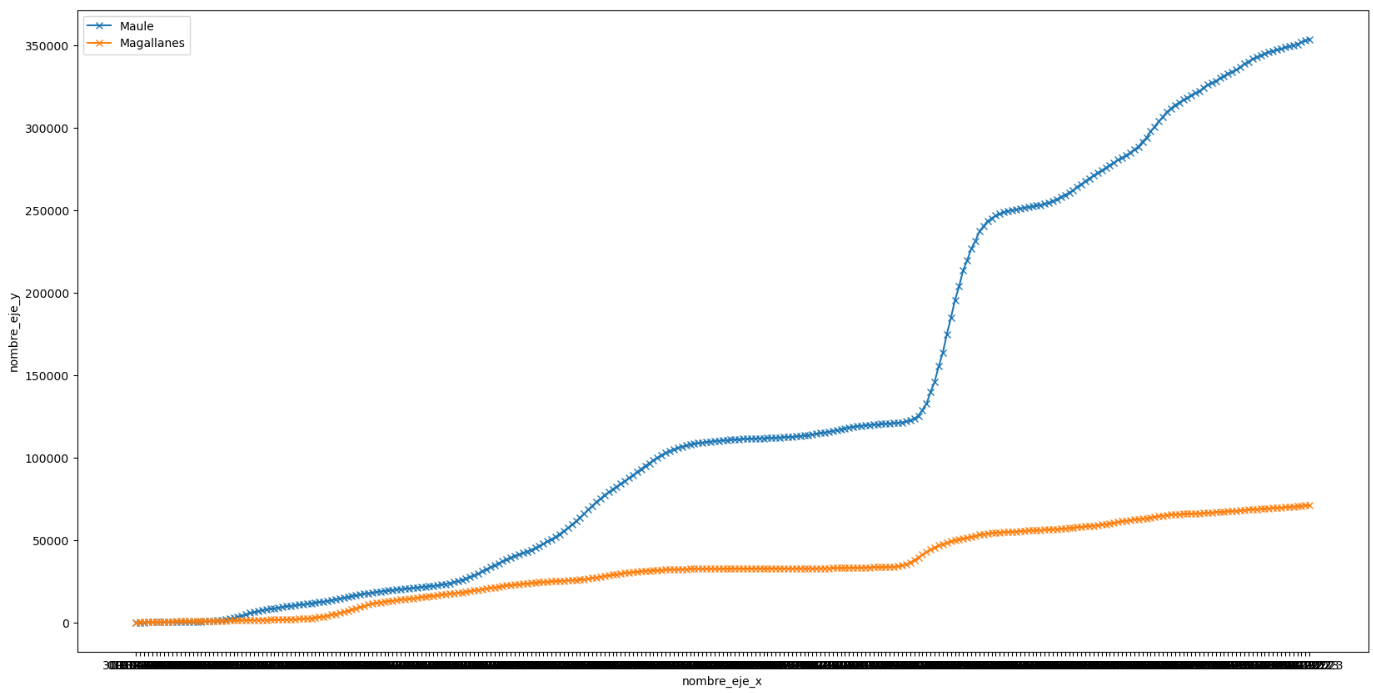

In [ ]:
# gráfico de barras vertical

fig, ax = plt.subplots()
ax.set_title("titulo")
ax.set_xlabel("nombre_eje_x")
ax.set_ylabel("nombre_eje_y") 
plt.bar(datos_eje_x, datos_eje_y, color="blue")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

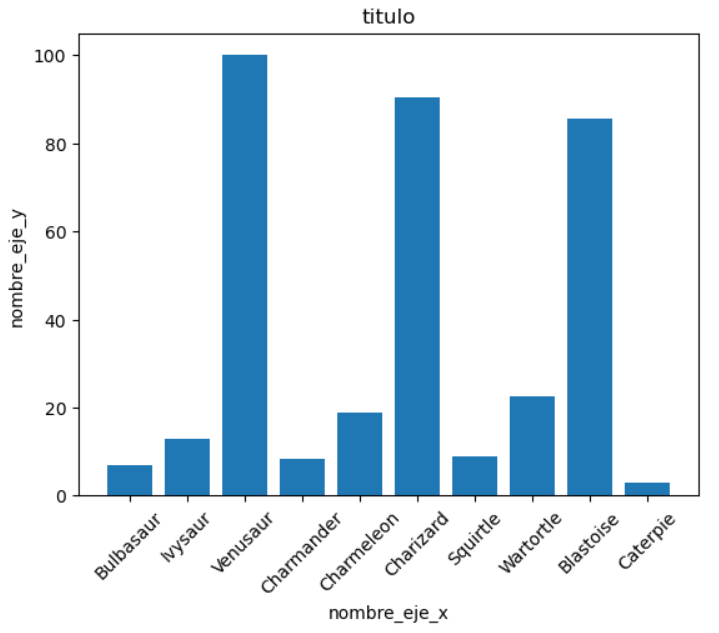

In [ ]:
# gráfico de barras horizontal

fig, ax = plt.subplots()
ax.set_title("titulo")
ax.set_xlabel("nombre_eje_x")
ax.set_ylabel("nombre_eje_y") 
plt.barh(datos_eje_x, datos_eje_y, color="blue")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

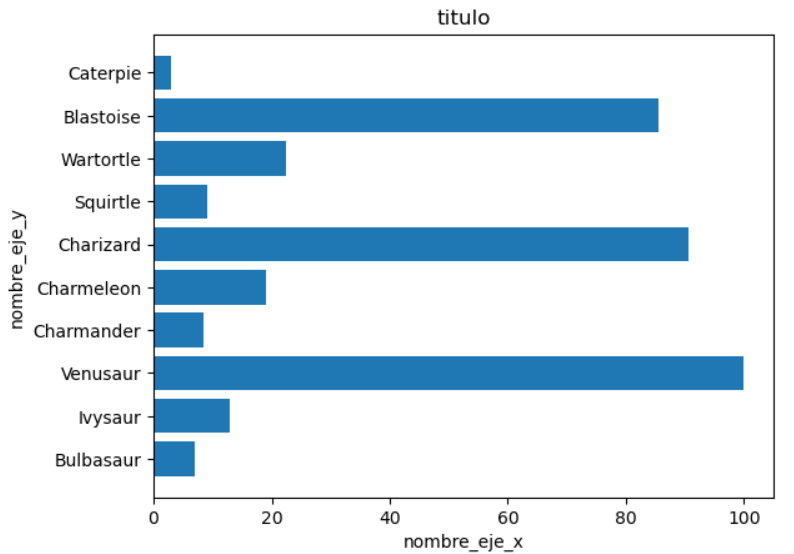

In [ ]:
# gráfico de bigotes

fig, ax = plt.subplots()
ax.set_title("titulo")
ax.set_xlabel("nombre_eje_x")
ax.set_ylabel("nombre_eje_y")
plt.boxplot(datos_para_el_grafico)
plt.xticks(etiqueta_bigote_superior, etiqueta_bigote_superior)
plt.show()

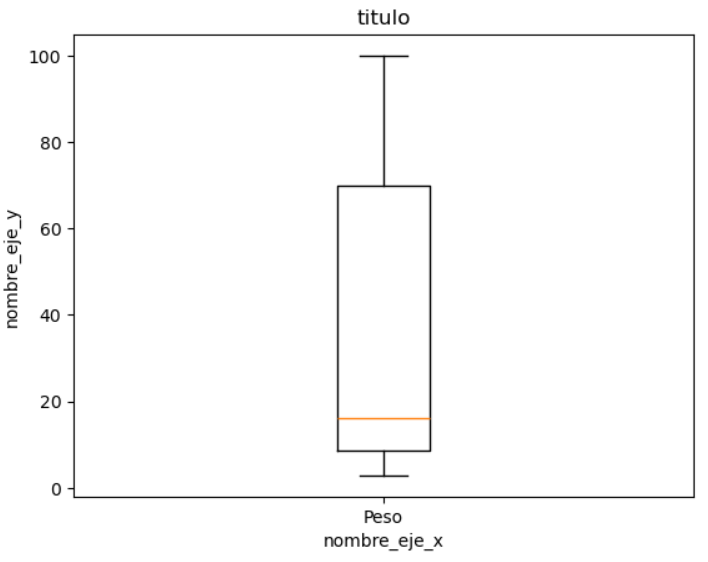

In [ ]:
# gráfico de puntos (scatter plot)

fig, ax = plt.subplots()
ax.set_title("titulo del grafico") 
ax.set_xlabel("nombre_eje_x")
ax.set_ylabel("nombre_eje_y")
plt.scatter(datos_eje_x, datos_eje_y)
plt.show()

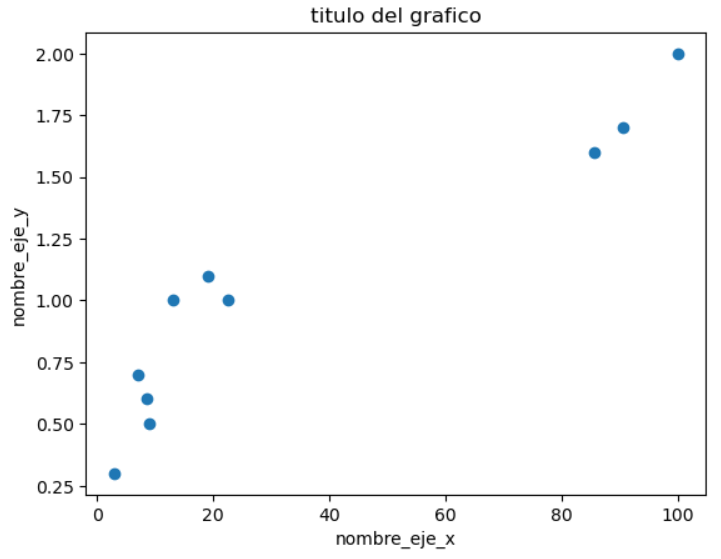

# Seaborn

In [ ]:
# hace muchos graficos del dataframe, es como lo mas util que pense en poner
sns.pairplot(dataframe)

#### informacion sobre los argumentos que recibe un histograma creado con seaborn

In [ ]:
# En Seaborn, los argumentos bins, stat y kde se utilizan en funciones que generan gráficos de distribución, como sns.histplot() o sns.kdeplot(). 
# Aquí te explico qué hace cada uno:

# bins: Este argumento se utiliza para definir el número de contenedores (o "bins") en un histograma. Puedes pasar un número entero que indique 
# cuántos bins quieres o una lista que especifique los límites de los bins. Por ejemplo:

# bins=30: Se crearán 30 bins.
# bins=[0, 1, 2, 3, 4]: Se crearán bins en los intervalos definidos.
# stat: Este argumento determina qué tipo de estadísticas se mostrarán en el gráfico. Las opciones comunes son:

# 'count': Muestra la cantidad de observaciones en cada bin (comportamiento predeterminado para histogramas).
# 'frequency': Muestra la frecuencia relativa de observaciones en cada bin.
# 'probability': Muestra la proporción de observaciones en cada bin.
# 'density': Normaliza el histograma para que el área total de los bins sume 1 (útil para comparaciones entre distribuciones).
# kde: Este argumento se utiliza para determinar si se debe incluir una estimación de la densidad de Kernel (KDE) en el gráfico. 
# Puedes establecerlo como True o False:

# kde=True: Se incluirá una curva KDE sobre el histograma.
# kde=False: No se incluirá la curva KDE.

In [ ]:
# scatterplt
# data es el dataframe, x e y pues las columnas
plt.figure(figsize=(10, 6))
sns.scatterplot(x='High_Confidence_Limit ', y='Data_Value', data=data)
plt.title('Relación entre Límite Superior de Confianza y Valor de Datos (Índice de Obesidad)')
plt.xlabel('Límite Superior de Confianza')
plt.ylabel('Valor de Datos (Índice de Obesidad)')
plt.show()

In [ ]:
# matriz de correlacion

corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# es un cuadrado de colores que da la correlacion (-1 a 1) de cada variable con las otras vaiables

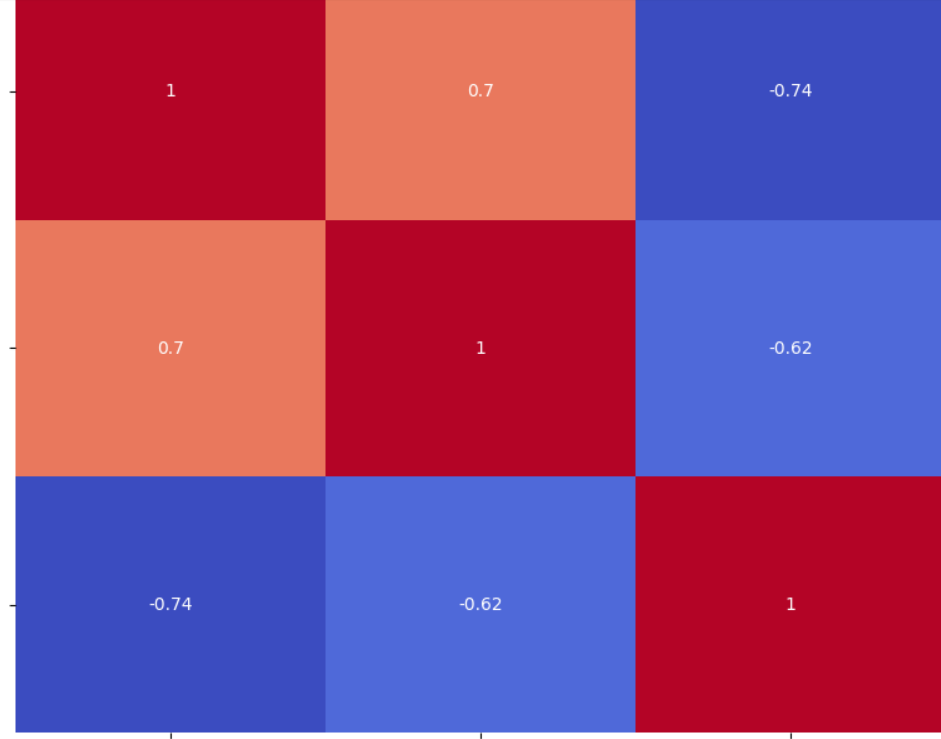